In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
cfe.settings.backend = "conda"

[11/03/2025 09:43:32] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

[11/03/2025 09:43:33] DEBUG    Reading data from '/root/PyCode/scRNA/data/Gastrulation/erythroid_lineage.h5ad'...                                                                                       
[11/03/2025 09:43:34] DEBUG    transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                 
[11/03/2025 09:43:35] DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'celltype' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                    

<Axes: title={'center': 'ref(celltype)'}, xlabel='X_umap1', ylabel='X_umap2'>

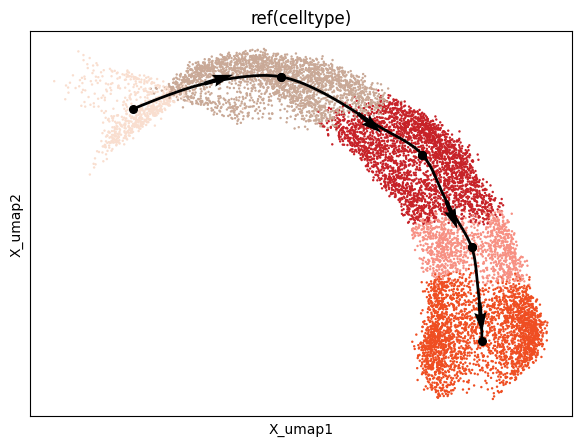

In [2]:
fadata = cfe.data.read_erythroid_lineage()
model_name = "20251031_154922__scvelo-conda__7F4URuYhlm"
fadata.load_trajectory_dict(model_name_list=[model_name])
cfe.plot.plot_trajectory(fadata)

其实画指定聚的降维图并不慢, 但还是添加了waypoint指定数量的函数

[11/03/2025 09:43:49] DEBUG    extract 'celltype' from prior infomation as parameter 'color'                                                                                                            
                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251031_154922__scvelo-conda__7F4URuYhlm, basis:X_umap.                                                               
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                            

<Axes: title={'center': 'scvelo-conda(celltype)'}, xlabel='X_umap1', ylabel='X_umap2'>

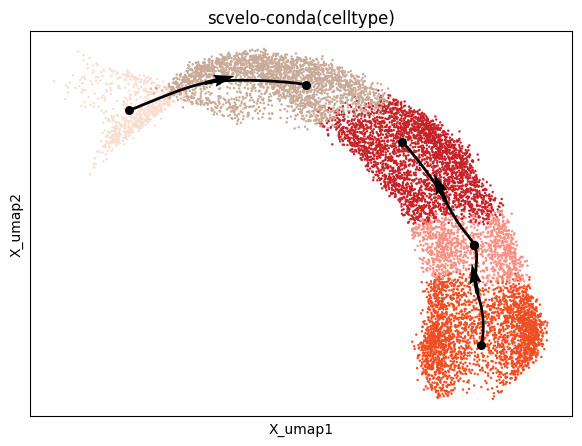

In [ ]:
cfe.plot.plot_trajectory(fadata, model_name=model_name, recompute_trajectory_embedding=True)

[11/03/2025 09:44:09] DEBUG    extract 'celltype' from prior infomation as parameter 'color'                                                                                                            
                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251031_154922__scvelo-conda__7F4URuYhlm, basis:X_umap.                                                               
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                            

<Axes: title={'center': 'scvelo-conda(celltype)'}, xlabel='X_umap1', ylabel='X_umap2'>

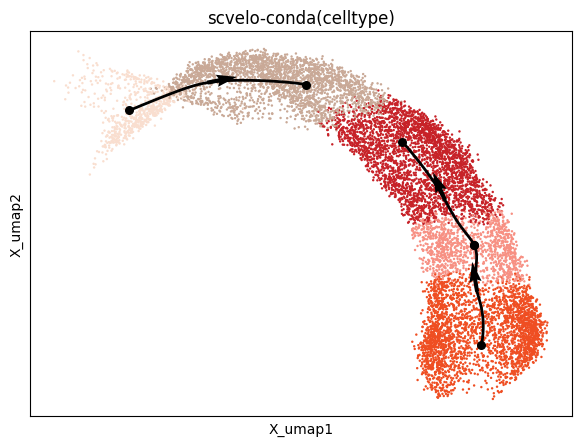

In [ ]:
waypoint_wrapper_kwargs = {"n_waypoints": 100}
cfe.plot.plot_trajectory(fadata, model_name=model_name, waypoint_wrapper_kwargs=waypoint_wrapper_kwargs, recompute_trajectory_embedding=True)
# 查看waypoint点数量
ww = fadata.get_waypoint_wrapper(model_name)
ww.waypoints

真正慢的是这里对于milestone颜色的绘制, 这是由于直接指定细的离散值颜色用scanpy绘制导致的, 尽可能避免这种绘制

[11/03/2025 09:46:04] DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251031_154922__scvelo-conda__7F4URuYhlm, basis:X_umap.                                                               
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[11/03/2025 09:46:13] DEBUG    add waypoints shape is (204, 9815) for '20251031_154922__scvelo-conda__7F4URuYhlm', finished!                                                                        

<Axes: title={'center': 'scvelo-conda(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

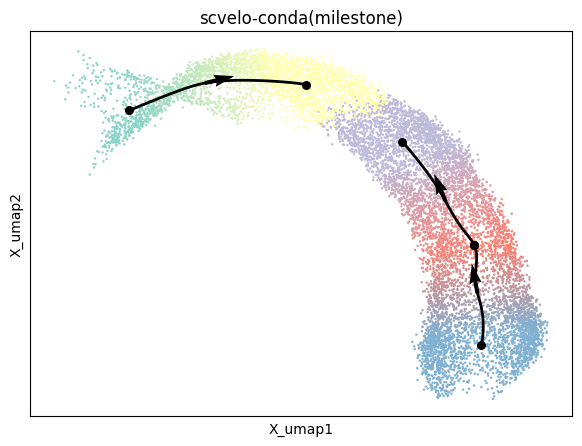

In [6]:
cfe.plot.plot_trajectory(fadata, color="milestone", model_name=model_name, recompute_trajectory_embedding=True)

In [8]:
import scanpy as sc

sc.pl.embedding(fadata, basis="umap", color="milestone")

ValueError: Image size of 924x69014 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>